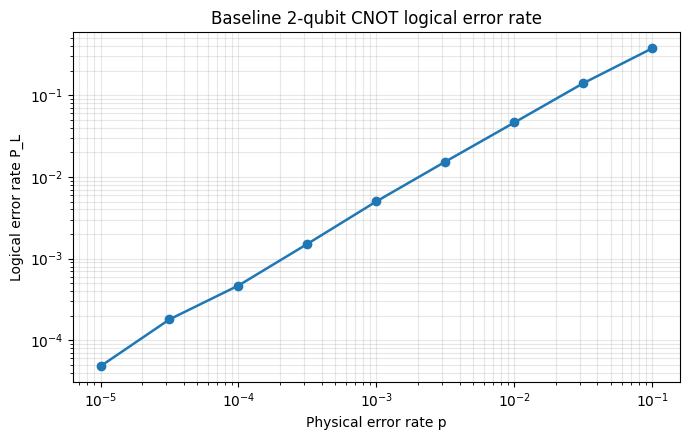

Saved baseline rates to: <workspace>/docs/example_notebooks/cnot_benchmark_result/logical_rates/baseline_2q_cnot_rates.npz
p=1.00e-05 -> P_L=0.000048
p=3.16e-05 -> P_L=0.000180
p=1.00e-04 -> P_L=0.000468
p=3.16e-04 -> P_L=0.001516
p=1.00e-03 -> P_L=0.005028
p=3.16e-03 -> P_L=0.015430
p=1.00e-02 -> P_L=0.046550
p=3.16e-02 -> P_L=0.141266
p=1.00e-01 -> P_L=0.378274
Loaded metadata:
  title: Baseline 2-qubit CNOT logical error rate
  description: Logical failure probability for a 2-qubit |00> -> CNOT -> ZZ readout baseline. A shot is a logical fail when measured bits are not 00. Noise uses EPIC StimLikeNoiseModel with matched p for reset flip, Clifford depolarization, and pre-measurement flip channels.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import stim

from pathlib import Path
from epic import StimLikeNoiseModel

# Baseline experiment: initialize |00>, apply CNOT, then measure both qubits in Z basis.
base_program = """
R 0 1
CX 0 1
M 0 1
""".strip()

noise_values = np.logspace(-5, -1, 9)
shots = 500_000
logical_error_rates = []

for p in noise_values:
    noise_model = StimLikeNoiseModel.from_stim_like_probabilities(
        after_clifford_depolarization=float(p),
        after_reset_flip_probability=float(p),
        before_measure_flip_probability=float(p),
    )
    noisy_program = noise_model.apply_model(base_program)
    circuit = stim.Circuit(noisy_program)

    samples = circuit.compile_sampler().sample(shots=shots)
    logical_failures = np.any(samples.astype(np.uint8), axis=1)
    logical_error_rates.append(float(np.mean(logical_failures)))

logical_error_rates = np.array(logical_error_rates)

result_title = "Baseline 2-qubit CNOT logical error rate"
result_description = (
    "Logical failure probability for a 2-qubit |00> -> CNOT -> ZZ readout baseline. "
    "A shot is a logical fail when measured bits are not 00. "
    "Noise uses EPIC StimLikeNoiseModel with matched p for reset flip, "
    "Clifford depolarization, and pre-measurement flip channels."
)

results_path = Path("baseline_2q_cnot_rates.npz")
results_path.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    results_path,
    noise_values=noise_values,
    logical_error_rates=logical_error_rates,
    shots=np.array([shots], dtype=np.int64),
    title=np.array([result_title]),
    description=np.array([result_description]),
)

plt.figure(figsize=(7, 4.5))
plt.plot(noise_values, logical_error_rates, marker="o", linewidth=1.8)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Physical error rate p")
plt.ylabel("Logical error rate P_L")
plt.title(result_title)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Saved baseline rates to: {results_path}")
for p, pl in zip(noise_values, logical_error_rates):
    print(f"p={p:.2e} -> P_L={pl:.6f}")

# Fast load pattern for later plotting:
loaded = np.load(results_path)
print("Loaded metadata:")
print(f"  title: {loaded['title'][0]}")
print(f"  description: {loaded['description'][0]}")

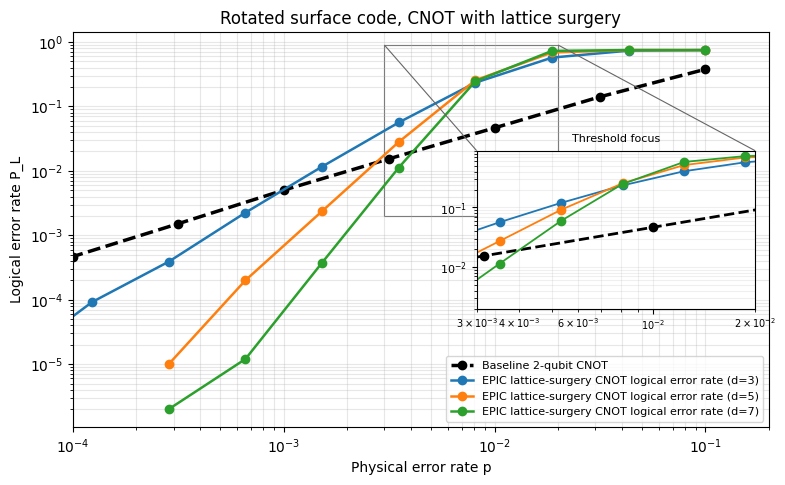

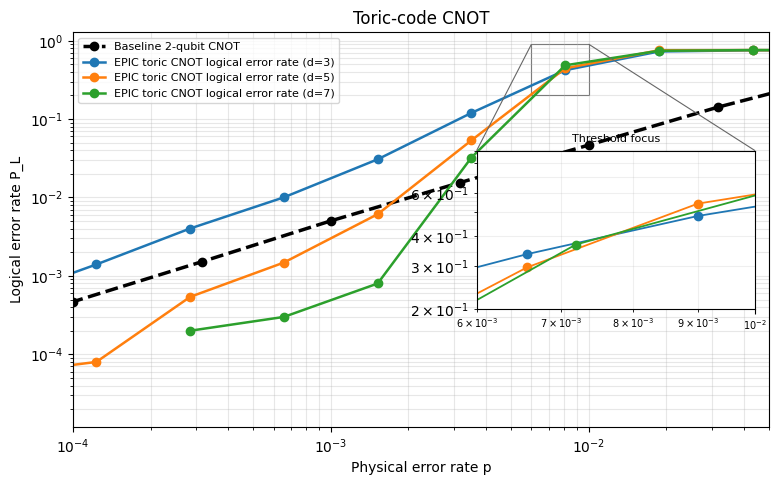

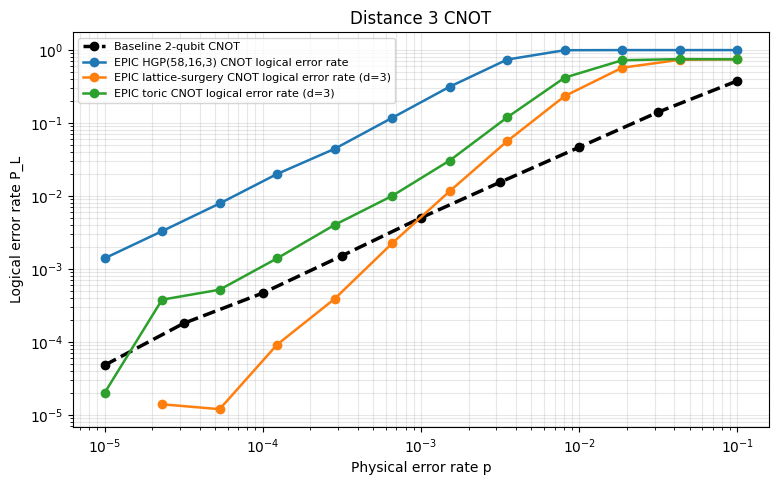

Loaded files for all-curves plot:
- baseline_2q_cnot_rates.npz
- hgp58_16_3_cnot_rates_big.npz
- ls_cnot_d3_rates.npz
- toric_cnot_d3_rates_big.npz


In [39]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

rates_dir = Path('.')
baseline_file = rates_dir / 'baseline_2q_cnot_rates.npz'


def load_curve(npz_path: Path) -> dict:
    data = np.load(npz_path, allow_pickle=True)
    title = data['title'][0] if 'title' in data else npz_path.stem
    return {
        'file': npz_path.name,
        'label': str(title),
        'noise_values': np.array(data['noise_values'], dtype=float),
        'logical_error_rates': np.array(data['logical_error_rates'], dtype=float),
    }


def get_curves(pattern: str) -> list[dict]:
    return [load_curve(path) for path in sorted(rates_dir.glob(pattern))]


def positive_points(curve: dict) -> tuple[np.ndarray, np.ndarray]:
    x = np.array(curve['noise_values'], dtype=float)
    y = np.array(curve['logical_error_rates'], dtype=float)
    mask = (x > 0) & (~np.isnan(y)) & (y > 0)
    return x[mask], y[mask]


def preferred_big_file(path: Path) -> Path:
    if path.name.endswith('_rates.npz'):
        candidate = path.with_name(path.name.replace('_rates.npz', '_rates_big.npz'))
        if candidate.exists():
            return candidate
    return path


def plot_curves(
    curves: list[dict],
    title: str,
    focus_curves: list[dict] | None = None,
    focus_xlim: tuple[float, float] | None = None,
    focus_ylim: tuple[float, float] | None = None,
    focus_title: str | None = None,
    main_xlim: tuple[float, float] | None = None,
    ) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))
    for curve in curves:
        x, y = positive_points(curve)
        if len(x) == 0:
            continue

        if curve['file'] == baseline_file.name:
            line = ax.plot(
                x,
                y,
                marker='o',
                linewidth=2.5,
                color='black',
                linestyle='--',
                label='Baseline 2-qubit CNOT',
            )[0]
        else:
            line = ax.plot(
                x,
                y,
                marker='o',
                linewidth=1.8,
                label=curve['label'],
            )[0]

    ax.set_xscale('log')
    ax.set_yscale('log')
    if main_xlim is not None:
        ax.set_xlim(*main_xlim)
    ax.set_xlabel('Physical error rate p')
    ax.set_ylabel('Logical error rate P_L')
    ax.set_title(title)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=8)

    if focus_curves:
        axins = inset_axes(ax, width='40%', height='40%', loc='center right', borderpad=1)
        for curve in focus_curves:
            x, y = positive_points(curve)
            if len(x) == 0:
                continue

            if curve['file'] == baseline_file.name:
                line = axins.plot(
                    x,
                    y,
                    marker='o',
                    linewidth=2.0,
                    color='black',
                    linestyle='--',
                )[0]
            else:
                line = axins.plot(
                    x,
                    y,
                    marker='o',
                    linewidth=1.3,
                )[0]

        axins.set_xscale('log')
        axins.set_yscale('log')
        if focus_xlim is not None:
            axins.set_xlim(*focus_xlim)
        if focus_ylim is not None:
            axins.set_ylim(*focus_ylim)
        axins.grid(True, which='both', alpha=0.2)
        axins.tick_params(axis='x', which='both', labelbottom=True, labelsize=7)
        axins.tick_params(axis='y', labelsize=8)
        if focus_title is not None:
            axins.set_title(focus_title, fontsize=8)
        inset_patch, connector1, connector2 = mark_inset(ax, axins, loc1=2, loc2=1, fc='none', ec='0.4', lw=0.8)
        axins.set_zorder(3)
        axins.patch.set_alpha(1.0)
        axins.patch.set_facecolor('white')
        inset_patch.set_zorder(0)
        connector1.set_zorder(0)
        connector2.set_zorder(0)

    fig.subplots_adjust(left=0.11, right=0.98, bottom=0.13, top=0.92)
    plt.show()


baseline_curve = load_curve(baseline_file)

# 1) Surface-code curves + baseline (lattice-surgery data).
surface_curves = [baseline_curve] + get_curves('ls_cnot_d*_rates.npz')
surface_curves_foc = [baseline_curve] + get_curves('ls_cnot_d*_rates_foc.npz')
plot_curves(
    surface_curves,
    'Rotated surface code, CNOT with lattice surgery',
    focus_curves=surface_curves_foc,
    focus_xlim=(3e-3, 2e-2),
    focus_ylim=(2e-3, 9e-1),
    focus_title='Threshold focus',
    main_xlim=(1e-4, 2e-1),
)

# 2) Toric-code curves + baseline using the new *_rates_big datasets.
toric_big_files = [
    rates_dir / 'toric_cnot_d3_rates_big.npz',
    rates_dir / 'toric_cnot_d5_rates_big.npz',
    rates_dir / 'toric_cnot_d7_rates_big.npz',
]
toric_curves = [baseline_curve] + [load_curve(path) for path in toric_big_files if path.exists()]
if len(toric_curves) == 1:
    toric_curves = [baseline_curve] + get_curves('toric_cnot_d*_rates.npz')
toric_curves_foc = [baseline_curve] + get_curves('toric_cnot_d*_rates_foc.npz')
plot_curves(
    toric_curves,
    'Toric-code CNOT',
    focus_curves=toric_curves_foc,
    focus_xlim=(6e-3, 1e-2),
    focus_ylim=(2e-1, 9e-1),
    focus_title='Threshold focus',
    main_xlim=(1e-4, 5e-2),
)

# 3) All available curves + baseline, but keep only d=3 for surface and toric families.
all_curves_raw = get_curves('*_rates.npz')
all_curves = [baseline_curve]
for c in all_curves_raw:
    source_path = preferred_big_file(rates_dir / c['file'])
    chosen_curve = load_curve(source_path)
    name = chosen_curve['file']
    if name == baseline_file.name:
        continue
    if name.startswith('ls_cnot_d') and name not in ('ls_cnot_d3_rates.npz', 'ls_cnot_d3_rates_big.npz'):
        continue
    if name.startswith('toric_cnot_d') and name not in ('toric_cnot_d3_rates.npz', 'toric_cnot_d3_rates_big.npz'):
        continue
    all_curves.append(chosen_curve)

plot_curves(all_curves, 'Distance 3 CNOT')

print('Loaded files for all-curves plot:')
for curve in all_curves:
    print(f"- {curve['file']}")